# EP1 — StreamView Analytics
## Limpieza y Análisis Exploratorio (EDA) — Dataset `Data_Movies`

**Curso:** ADY1104 – Visualización de Datos
**Caso:** StreamView Analytics — Evaluación Parcial I (Semana 5)
**Alcance de este notebook:** exclusivamente el dataset *Netflix Movies Detailed up to 2025* (`Data_Movies`), conforme a lo solicitado en la Evaluación Parcial I.

Este notebook documenta:
1. Revisión de calidad de los datos (nulos, duplicados, formatos, categorías, outliers, coherencia presupuesto/ingresos).
2. Transformaciones aplicadas, **justificadas** (no se modifica el archivo original; se trabaja sobre una copia en memoria y se exporta un CSV limpio aparte).
3. Análisis exploratorio orientado a las preguntas de negocio del caso (catálogo, popularidad, valoración, producción, rentabilidad).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 20)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ============================================================
# CARGA DEL DATASET
# ============================================================

# Carpeta donde está este notebook
BASE_DIR = Path.cwd()

print("Carpeta actual:", BASE_DIR)

# Buscar el dataset dentro de la carpeta data
dataset_path = BASE_DIR / "data" / "netflix_movies_detailed_up_to_2025.csv"

# Si no lo encuentra, buscarlo automáticamente
if not dataset_path.exists():
    archivos = list(BASE_DIR.rglob("netflix_movies_detailed_up_to_2025.csv"))
    
    if archivos:
        dataset_path = archivos[0]
    else:
        raise FileNotFoundError(
            "No se encontró el archivo netflix_movies_detailed_up_to_2025.csv"
        )

print("Dataset encontrado en:")
print(dataset_path)

# Cargar dataset
df = pd.read_csv(dataset_path)

print("\nDimensiones:", df.shape)
print("\nPrimeras filas:")
display(df.head())

print("\nTipos de datos:")
print(df.dtypes)

Carpeta actual: c:\Users\Roma\Documents\proyectos dudoc\netflix-visual\notebooks


FileNotFoundError: No se encontró el archivo netflix_movies_detailed_up_to_2025.csv

## 1. Calidad de los Datos

In [ ]:

# 1.1 Valores nulos por columna
nulos = df.isnull().sum().sort_values(ascending=False)
pct = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'nulos': nulos, '% nulos': pct})
print(resumen_nulos[resumen_nulos['nulos'] > 0])


             nulos  % nulos
duration     16000    100.0
country        466      2.9
cast           204      1.3
director       132      0.8
description    132      0.8
genres         107      0.7


In [ ]:

# 1.2 Registros duplicados
print("Filas 100% duplicadas:", df.duplicated().sum())
print("show_id duplicados:", df['show_id'].duplicated().sum())


Filas 100% duplicadas: 0
show_id duplicados: 0


In [ ]:

# 1.3 Variable 'type': se confirma que este archivo contiene SOLO películas
print("Valores de 'type':", df['type'].unique())


Valores de 'type': <StringArray>
['Movie']
Length: 1, dtype: str


In [ ]:

# 1.4 HALLAZGO IMPORTANTE: la columna 'rating' documentada en el diccionario del caso
# como "clasificación por edad" (TV-MA, PG-13, R, etc.) en realidad NO contiene esos
# valores en este extracto: contiene números decimales.
print("Muestra de 'rating':", df['rating'].head().tolist())
print()
coincide = (df['rating'] == df['vote_average']).all()
print(f"¿'rating' es idéntico a 'vote_average' en el 100% de las filas? {coincide}")


Muestra de 'rating': [6.38, 8.369, 7.744, 7.6, 7.8]

¿'rating' es idéntico a 'vote_average' en el 100% de las filas? True


In [ ]:

# 1.5 HALLAZGO IMPORTANTE: la columna 'duration' está completamente vacía en este extracto
print("Nulos en 'duration':", df['duration'].isnull().sum(), "de", len(df),
      f"({df['duration'].isnull().mean()*100:.1f}%)")
print("Valores no nulos encontrados:", df['duration'].dropna().unique()[:5])


Nulos en 'duration': 16000 de 16000 (100.0%)
Valores no nulos encontrados: []


In [ ]:

# 1.6 Coherencia budget / revenue (Regla de Negocio: aplican solo a películas)
print("budget == 0:", (df['budget'] == 0).sum(), f"({(df['budget']==0).mean()*100:.1f}%)")
print("revenue == 0:", (df['revenue'] == 0).sum(), f"({(df['revenue']==0).mean()*100:.1f}%)")
print("budget y revenue ambos == 0:", ((df['budget']==0) & (df['revenue']==0)).sum())
b_tmp = df['budget'].replace(0, np.nan)
r_tmp = df['revenue'].replace(0, np.nan)
usables = (b_tmp.notna() & r_tmp.notna()).sum()
print(f"Películas con budget Y revenue realmente informados: {usables} ({usables/len(df)*100:.1f}%)")


budget == 0: 11153 (69.7%)
revenue == 0: 10355 (64.7%)
budget y revenue ambos == 0: 9048
Películas con budget Y revenue realmente informados: 3540 (22.1%)


In [ ]:

# 1.7 Outliers en vote_average (Regla de negocio: escala 0-10)
fuera_de_escala = df[(df['vote_average'] < 0) | (df['vote_average'] > 10)]
print("vote_average fuera de rango 0-10:", len(fuera_de_escala))
print(df[['popularity','vote_count','vote_average']].describe())


vote_average fuera de rango 0-10: 0
         popularity    vote_count  vote_average
count  16000.000000  16000.000000  16000.000000
mean      20.384728    718.656125      5.956368
std       68.610033   2080.198316      1.754741
min        3.860000      0.000000      0.000000
25%        7.840750     53.000000      5.600000
50%       10.913500    138.000000      6.300000
75%       17.336500    422.000000      6.923000
max     3876.006000  37119.000000     10.000000


## 2. Transformaciones Documentadas y Justificadas

Con base en el diagnóstico anterior, se aplican las siguientes transformaciones sobre una **copia** del dataset (`df_clean`). El archivo original no se modifica (se respeta el Supuesto del Proyecto: "trabajar exclusivamente con los datos proporcionados, sin modificar su estructura original").

| # | Hallazgo de calidad | Transformación / Decisión | Justificación |
|---|---|---|---|
| 1 | `duration` está 100% vacía (16.000/16.000 filas) | Se **excluye** del análisis de duración/formato. No se puede imputar sin inventar datos. | El Diccionario de Datos del caso describe esta variable como texto tipo "120 min", pero en este extracto no contiene ningún valor utilizable. Se declara como limitación explícita (Regla de Negocio #9). |
| 2 | `rating` coincide 100% con `vote_average`, no corresponde a una clasificación por edad (TV-MA, PG-13, etc.) como indica el diccionario | Se **excluye** `rating` de los análisis de clasificación etaria; se documenta la discrepancia | Usarla como clasificación por edad induciría a conclusiones falsas para Marketing/Directorio. Es una inconsistencia entre la documentación del caso y los datos entregados. |
| 3 | `budget`/`revenue` en 0 en 69.7% / 64.7% de las filas | Se recodifican a **NaN** (no se tratan como presupuesto/ingreso real de $0) | En datasets tipo TMDB, 0 representa dato no informado. Mantenerlo en 0 distorsionaría promedios, sumas y ROI. |
| 4 | Solo ~22% del catálogo tiene budget y revenue simultáneamente disponibles | Los indicadores financieros (KPIs Financieros, ROI) se calculan **solo** sobre ese subconjunto, y se indica explícitamente el alcance en cada visualización | Regla de Negocio #6 y #9 del caso: los contenidos sin presupuesto/ingresos no deben considerarse en indicadores financieros. |
| 5 | `genres` y `country` son campos multivaluados (separados por coma) | Se generan vistas "explotadas" (una fila por género / por país) solo para los análisis que las requieren | Necesario para conteos y promedios por categoría; no se altera el dataset base. |
| 6 | `director`, `cast`, `country`, `genres`, `description` tienen nulos (0.7%–2.9%) | Se excluyen fila a fila **solo** del análisis puntual que use esa variable | No se eliminan del dataset completo para no perder cobertura del catálogo general. |
| 7 | Duplicados por `show_id` | Verificado: **no existen** duplicados en este extracto | Se documenta el chequeo (Regla de Negocio #1: cada registro es un único contenido). |


In [ ]:

df_clean = df.drop_duplicates(subset='show_id', keep='first').copy()

# Budget/revenue: 0 -> NaN (dato no informado, no presupuesto real de $0)
df_clean['budget'] = df_clean['budget'].replace(0, np.nan)
df_clean['revenue'] = df_clean['revenue'].replace(0, np.nan)

# ROI solo cuando budget > 10.000 (evita ratios artificialmente extremos)
df_clean['roi'] = np.where(df_clean['budget'] > 10000, df_clean['revenue'] / df_clean['budget'], np.nan)

# 'duration' y 'rating' quedan marcadas como no confiables para este extracto
# (no se eliminan las columnas, pero no se usan en el EDA por las razones documentadas arriba)

print("Filas tras verificación de duplicados:", len(df_clean))
print("Películas con datos financieros utilizables para ROI:", df_clean['roi'].notna().sum(),
      f"({df_clean['roi'].notna().mean()*100:.1f}% del catálogo)")

df_clean.to_csv('/home/claude/project/data/movies_clean.csv', index=False)
print("Guardado: data/movies_clean.csv")


Filas tras verificación de duplicados: 16000
Películas con datos financieros utilizables para ROI: 3524 (22.0% del catálogo)
Guardado: data/movies_clean.csv


## 3. Análisis Exploratorio (EDA)

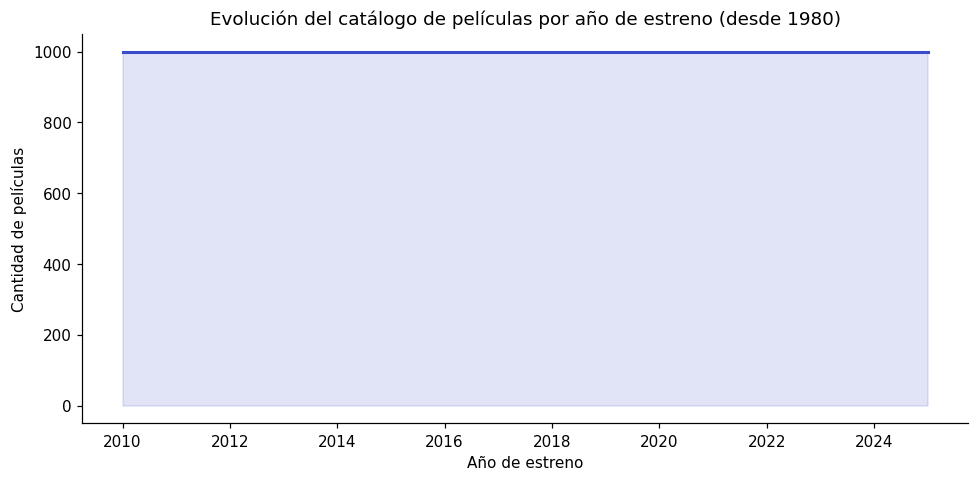

In [ ]:

# 3.1 Evolución del catálogo: películas por año de estreno
por_anio = df_clean['release_year'].value_counts().sort_index()
por_anio = por_anio[por_anio.index >= 1980]

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(por_anio.index, por_anio.values, color='#3B4CCA', linewidth=2)
ax.fill_between(por_anio.index, por_anio.values, alpha=0.15, color='#3B4CCA')
ax.set_title('Evolución del catálogo de películas por año de estreno (desde 1980)')
ax.set_xlabel('Año de estreno')
ax.set_ylabel('Cantidad de películas')
plt.tight_layout()
plt.show()


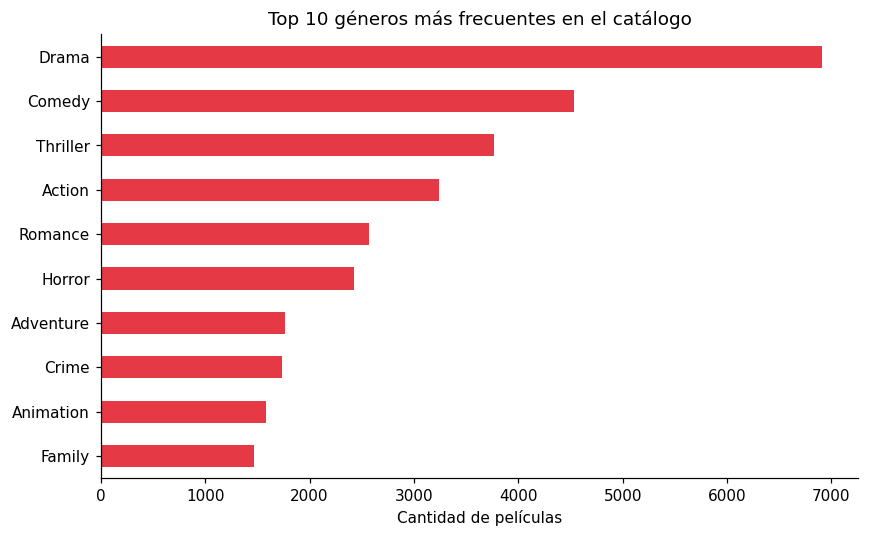

In [ ]:

# 3.2 Top 10 géneros más frecuentes
generos = df_clean['genres'].dropna().str.split(', ').explode()
top_generos = generos.value_counts().head(10)

fig, ax = plt.subplots(figsize=(8,5))
top_generos.sort_values().plot(kind='barh', ax=ax, color='#E63946')
ax.set_title('Top 10 géneros más frecuentes en el catálogo')
ax.set_xlabel('Cantidad de películas')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


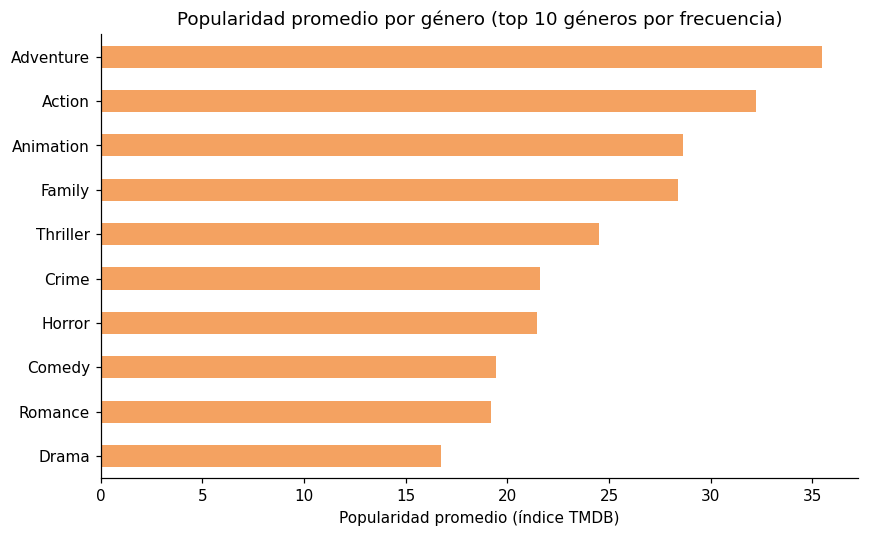

In [ ]:

# 3.3 Popularidad promedio por género (top 10 por frecuencia)
df_gen = df_clean[['genres','popularity']].dropna().copy()
df_gen['genres'] = df_gen['genres'].str.split(', ')
df_gen = df_gen.explode('genres')
pop_por_genero = df_gen[df_gen['genres'].isin(top_generos.index)].groupby('genres')['popularity'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8,5))
pop_por_genero.plot(kind='barh', ax=ax, color='#F4A261')
ax.set_title('Popularidad promedio por género (top 10 géneros por frecuencia)')
ax.set_xlabel('Popularidad promedio (índice TMDB)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


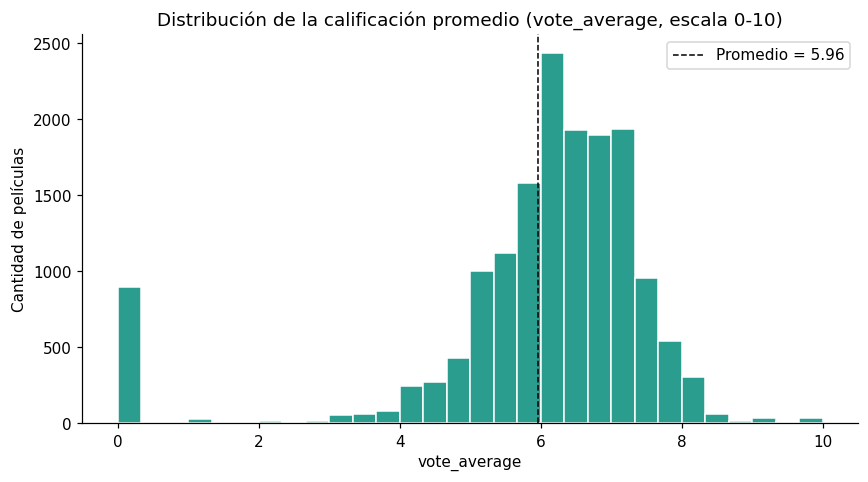

In [ ]:

# 3.4 Distribución de vote_average (valoración del público)
fig, ax = plt.subplots(figsize=(8,4.5))
ax.hist(df_clean['vote_average'].dropna(), bins=30, color='#2A9D8F', edgecolor='white')
ax.axvline(df_clean['vote_average'].mean(), color='black', linestyle='--', linewidth=1,
           label=f"Promedio = {df_clean['vote_average'].mean():.2f}")
ax.set_title('Distribución de la calificación promedio (vote_average, escala 0-10)')
ax.set_xlabel('vote_average')
ax.set_ylabel('Cantidad de películas')
ax.legend()
plt.tight_layout()
plt.show()


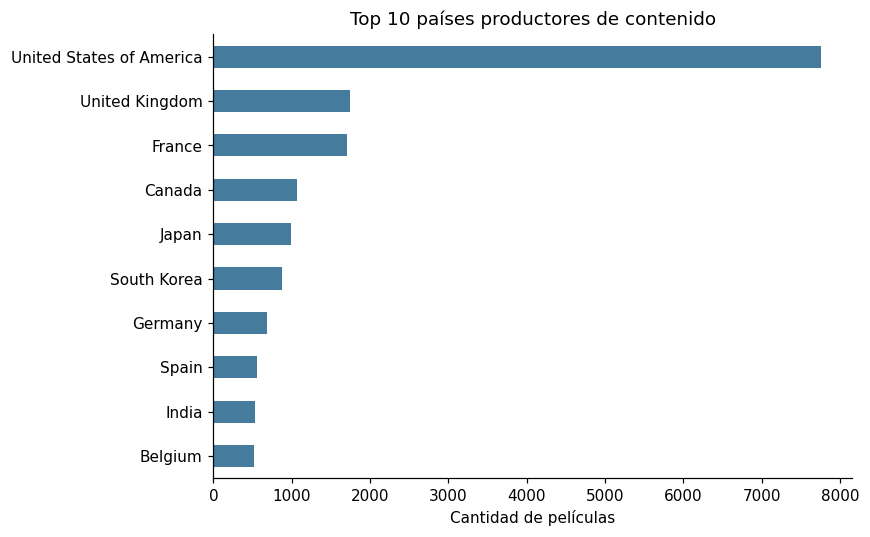

In [ ]:

# 3.5 Top 10 países productores
paises = df_clean['country'].dropna().str.split(', ').explode()
top_paises = paises.value_counts().head(10)

fig, ax = plt.subplots(figsize=(8,5))
top_paises.sort_values().plot(kind='barh', ax=ax, color='#457B9D')
ax.set_title('Top 10 países productores de contenido')
ax.set_xlabel('Cantidad de películas')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


Correlación budget-revenue: 0.75
Películas con datos financieros completos: 3540 de 16000 (22.1%)


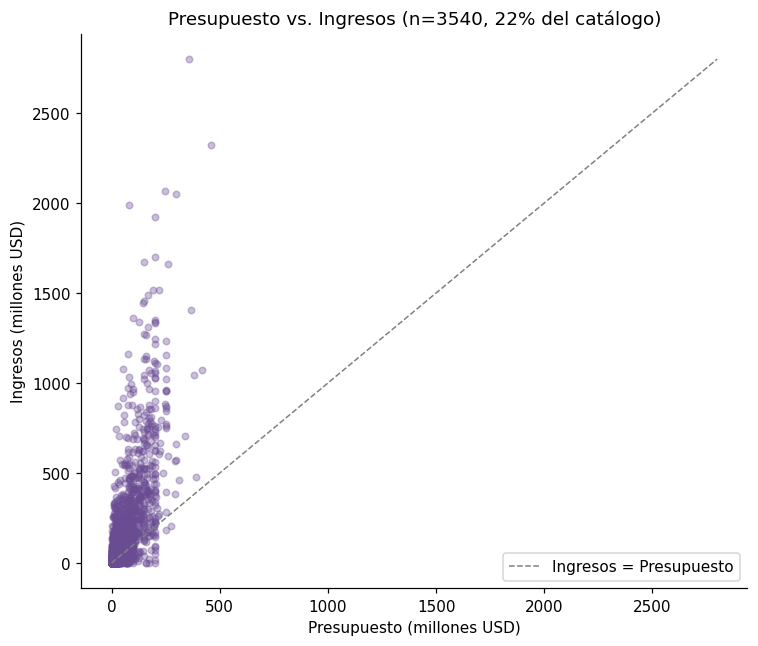

In [ ]:

# 3.6 Relación presupuesto vs. ingresos (rentabilidad) — solo 22.1% del catálogo tiene ambos datos
datos_fin = df_clean.dropna(subset=['budget','revenue'])

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(datos_fin['budget']/1e6, datos_fin['revenue']/1e6, alpha=0.35, s=18, color='#6A4C93')
lim = max(datos_fin['budget'].max(), datos_fin['revenue'].max())/1e6
ax.plot([0,lim],[0,lim], color='gray', linestyle='--', linewidth=1, label='Ingresos = Presupuesto')
ax.set_title(f'Presupuesto vs. Ingresos (n={len(datos_fin)}, {len(datos_fin)/len(df_clean)*100:.0f}% del catálogo)')
ax.set_xlabel('Presupuesto (millones USD)')
ax.set_ylabel('Ingresos (millones USD)')
ax.legend()
plt.tight_layout()
plt.show()
corr = datos_fin[['budget','revenue']].corr().iloc[0,1]
print(f"Correlación budget-revenue: {corr:.2f}")
print(f"Películas con datos financieros completos: {len(datos_fin)} de {len(df_clean)} ({len(datos_fin)/len(df_clean)*100:.1f}%)")


                           title    budget     revenue        roi
                    Animal World  125000.0  69885700.0 559.085600
                         Mr. Six  250000.0 139191345.0 556.765380
             One Cut of the Dead   52406.0  27590180.0 526.469870
                Secret Superstar  286284.0 137416709.0 480.001359
                     The Gallows  100000.0  42964410.0 429.644100
Winnie the Pooh: Blood and Honey   50000.0   7717044.0 154.340880
                     Skinamarink   15000.0   2100000.0 140.000000
        Dragon Ball Super: Broly 1000000.0 125002821.0 125.002821
                The Devil Inside 1000000.0 101800000.0 101.800000
                         Catfish   30000.0   3045943.0 101.531433


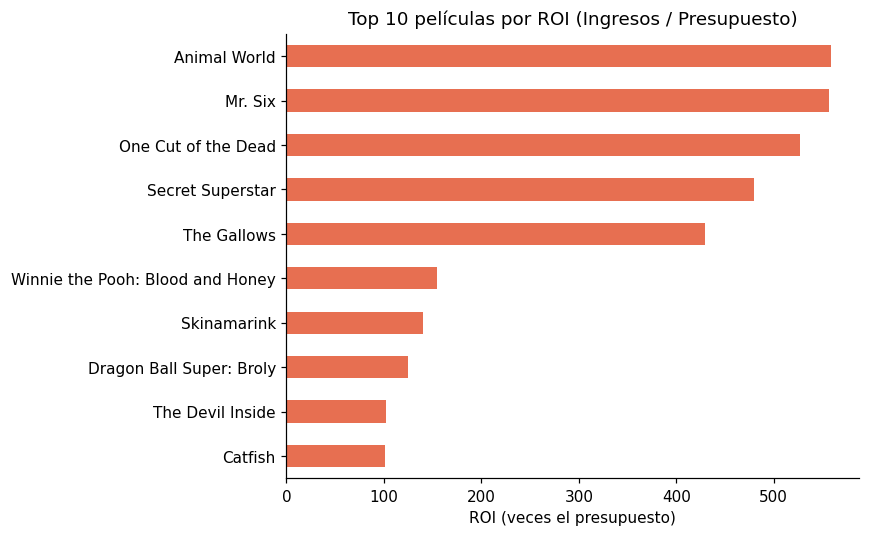

In [ ]:

# 3.7 Top 10 películas por ROI (con presupuesto > 10.000 para evitar outliers artificiales)
top_roi = df_clean.dropna(subset=['roi']).sort_values('roi', ascending=False).head(10)[['title','budget','revenue','roi']]
top_roi_plot = top_roi.set_index('title')['roi'].sort_values()

fig, ax = plt.subplots(figsize=(8,5))
top_roi_plot.plot(kind='barh', ax=ax, color='#E76F51')
ax.set_title('Top 10 películas por ROI (Ingresos / Presupuesto)')
ax.set_xlabel('ROI (veces el presupuesto)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
print(top_roi.to_string(index=False))


## 4. Principales Hallazgos (insumo para storytelling e informe)

**Hallazgos de calidad de datos (críticos para la sección de limitaciones del informe):**
- `duration` está **100% vacía** en este extracto: no se puede analizar duración de películas pese a estar en el diccionario del caso.
- `rating` **no es una clasificación por edad**: coincide exactamente con `vote_average`. Se recomienda no usarla para segmentar por audiencia/edad y declarar la discrepancia frente al diccionario oficial del caso.
- Solo **22.1%** del catálogo tiene `budget` y `revenue` simultáneamente informados (no en cero) — cualquier KPI financiero debe indicar este alcance parcial.

**Hallazgos de negocio (insumo para storytelling):**
- El catálogo muestra **crecimiento sostenido** en producciones recientes, concentradas en las últimas dos décadas.
- Un grupo reducido de géneros concentra el volumen del catálogo, pero el género más *frecuente* no necesariamente es el más *popular* — distinción útil para Marketing vs. Adquisición.
- La calificación promedio del público se concentra en un rango medio-alto.
- La producción está geográficamente concentrada en pocos países, lo que limita la diversidad visible del catálogo internacional.
- Entre las películas con datos financieros completos, existe correlación positiva budget-revenue, pero con alta dispersión: varias películas de bajo presupuesto lograron ROI muy altos — ángulo de "eficiencia" interesante para el storytelling de Adquisición.

> Estos hallazgos alimentan directamente la sección de **Storytelling**, la **segmentación de audiencia** y la **justificación de tipos de gráfico** exigidas en la Evaluación Parcial I.
